###Introducción
En este reporte se busca analizar el nivel de felicidad de distintos países. Para esto se utilizará una base de datos donde se buscarán relaciones entre distintos factores que afecten y tengan influencia sobre el nivel de felicidad. Para esto, este reporte utiliza datos del World Happiness Report de 2022 y datos de GDP de 2020. Se analizan 141 países y las dos variables que se utilizan son el nivel de felicidad y el producto interno bruto de cada país. Esto se hace para buscar una correlación entre el nivel de felicidad y el dinero y conocer si realmente el dinero "da la felicidad". Realmente, solo analizando el GDP no es suficiente para explicar el nivel de felicidad en cada país, por lo que luego se utilizará una base de datos que suma 3 variables al estudio, para buscar más correlaciones.


In [ ]:
import pandas as pd
import os

# Cargar el archivo CSV en un DataFrame desde la ruta correcta
df_felicidad_gdp = pd.read_csv('/content/sample_data/A1.2 Felicidad y GDP.csv')

# Mostrar las primeras 5 filas del DataFrame
display(df_felicidad_gdp)

,Pais,Felicidad,GDP
0,Finland,7.8210,2.718370e+11
1,Denmark,7.6362,3.560850e+11
2,Iceland,7.5575,2.171808e+10
3,Switzerland,7.5116,7.522480e+11
4,Netherlands,7.4149,9.138650e+11
...,...,...,...
136,Botswana,3.4711,1.493007e+10
137,Rwanda,3.2682,1.018435e+10
138,Zimbabwe,2.9951,1.805117e+10
139,Lebanon,2.9553,2.594892e+10


  Esta tabla contiene todos los países que serán analizados. Este análisis será llevado a cabo observando dos variables:
  

*   Felicidad
*   Producto interno bruto

Pero antes de analizar tenemos que entender bien que significan estas dos variables por las que se regirá el estudio.

Felicidad es un estado emocional y mental de satisfacción, bienestar y plenitud. Este estado es subjetivo que suele ser caracterizado por emociones positivas.
El producto interno bruto es el valor monetario total de todos los bienes y servicios finales producidos por un país durante un periodo determinado.

Es importante conocer el significado de estas dos variables y el porque se utilizan específicamente. Actualmente hay una corriente de pensamiento que induce a pensar que el dinero da la felicidad. Es por eso que realizar la comparación y observar correlaciones entre el dinero que posee un país y el nivel de felicidad que tiene puede ayudar a confirmar o desmentir este pensamiento.



###Modelo de regresión lineal simple

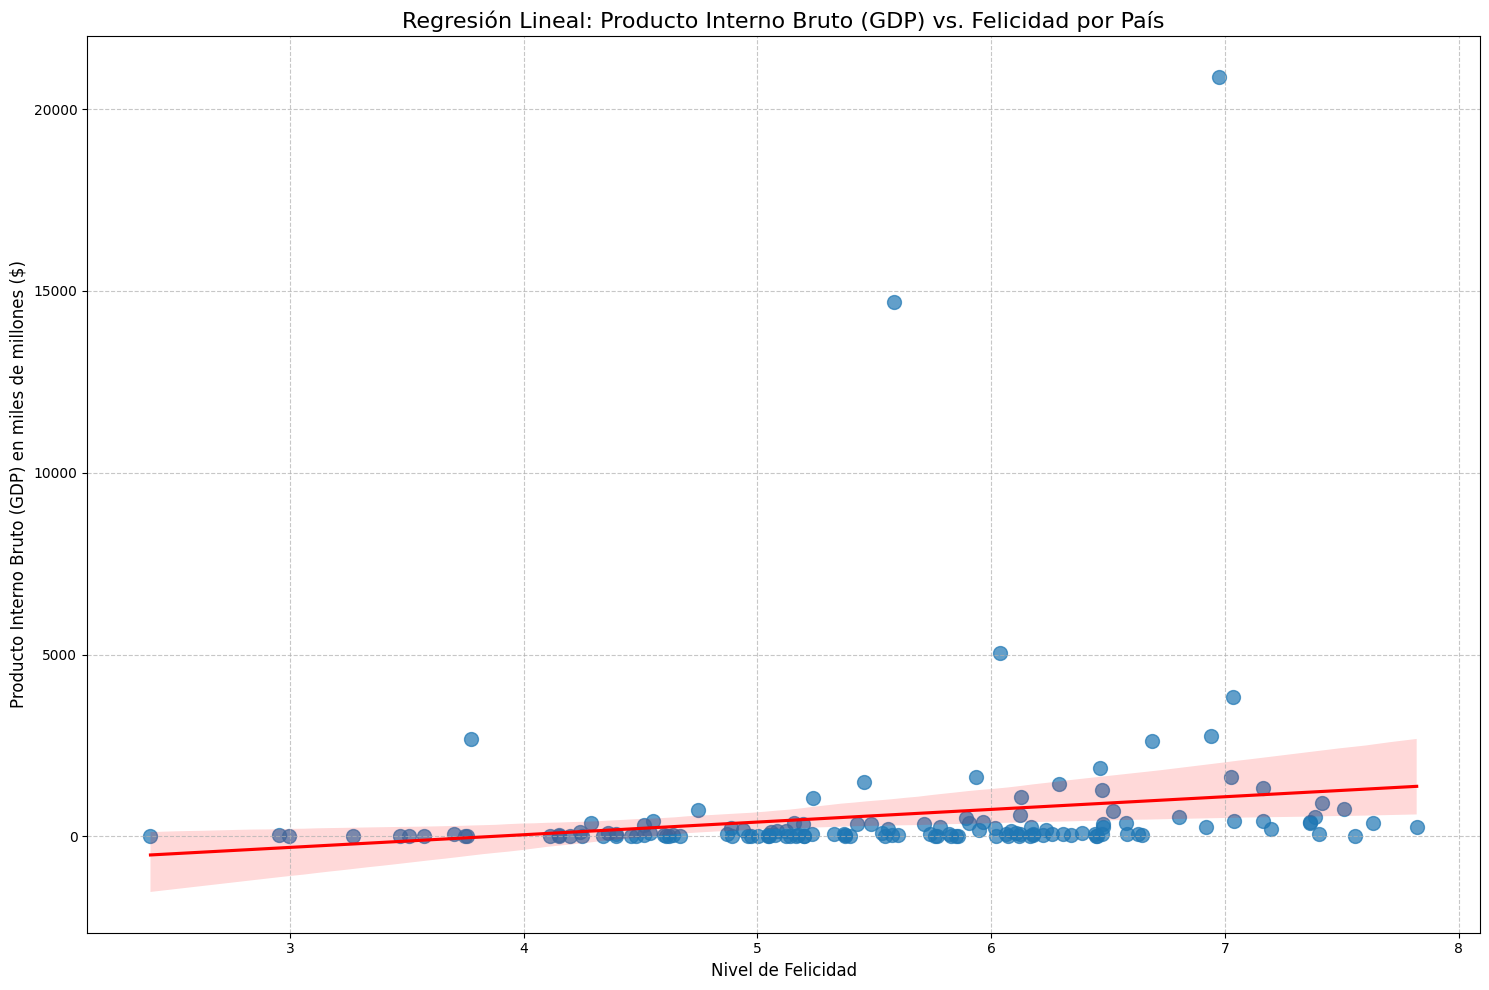

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV en un DataFrame desde la ruta correcta (incluido para asegurar que df_felicidad_gdp esté definido)
df_felicidad_gdp = pd.read_csv('/content/sample_data/A1.2 Felicidad y GDP.csv')

# Crear una nueva columna para el GDP en miles de millones si no existe
df_felicidad_gdp['GDP_billions'] = df_felicidad_gdp['GDP'] / 1e9

# Crear el gráfico de regresión lineal con los ejes intercambiados y GDP escalado
plt.figure(figsize=(15, 10))
sns.regplot(x='Felicidad', y='GDP_billions', data=df_felicidad_gdp, scatter_kws={'s': 100, 'alpha': 0.7}, line_kws={'color': 'red'})

# Establecer título y etiquetas de los ejes actualizados
plt.title('Regresión Lineal: Producto Interno Bruto (GDP) vs. Felicidad por País', fontsize=16)
plt.xlabel('Nivel de Felicidad', fontsize=12)
plt.ylabel('Producto Interno Bruto (GDP) en miles de millones ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

In [ ]:
import pandas as pd

# Cargar el archivo CSV en un DataFrame desde la ruta correcta (incluido para asegurar que df_felicidad_gdp esté definido)
df_felicidad_gdp = pd.read_csv('/content/sample_data/A1.2 Felicidad y GDP.csv')

# Crear una nueva columna para el GDP en miles de millones si no existe
df_felicidad_gdp['GDP_billions'] = df_felicidad_gdp['GDP'] / 1e9

# Calcular la media de 'Felicidad' y 'GDP_billions'
mean_felicidad = df_felicidad_gdp['Felicidad'].mean()
mean_gdp_billions = df_felicidad_gdp['GDP_billions'].mean()

# Calcular el coeficiente de correlación de Pearson entre 'Felicidad' y 'GDP_billions'
correlation_coefficient = df_felicidad_gdp['Felicidad'].corr(df_felicidad_gdp['GDP_billions'])

print(f"Media del Nivel de Felicidad: {mean_felicidad:.2f}")
print(f"Media del Producto Interno Bruto (GDP) en miles de millones: {mean_gdp_billions:.2f}")
print(f"Coeficiente de Correlación (Pearson) entre Felicidad y GDP: {correlation_coefficient:.2f}")

Media del Nivel de Felicidad: 5.56
Media del Producto Interno Bruto (GDP) en miles de millones: 588.99
Coeficiente de Correlación (Pearson) entre Felicidad y GDP: 0.17


En esta gráfica observamos la relación entre el GDP y la felicidad. Se observa que los países que lideran el GBP son Estados Unidos o China, aunque hay diferencia de posiciones en el nivel de felicidad entre los dos países. Aunque existe una tendencia positiva, el coeficiente de correlación de Pearson es bajo (0.17), lo que indica una relación lineal débil. Es importante notar que el GDP presenta grandes diferencias de escala entre países (órdenes de magnitud), lo que sugiere que una transformación de los datos podría ser necesaria para mejorar el ajuste. Al analizar la pendiente del modelo de regresión, observamos que por cada mil millones de dólares de aumento en el GDP, el nivel de felicidad incrementa en x unidades, aunque se debe validar si este efecto es estadísticamente significativo.

In [ ]:
df_happy = pd.read_csv("https://raw.githubusercontent.com/kirenz/datasets/master/happy.csv")
df_happy = df_happy.rename(columns={
    "Happiness.Score": "Felicidad",
    "Economy..GDP.per.Capita.": "GDP_per_capita",
    "Health..Life.Expectancy.": "Esperanza_vida",
})
# Renombrar country a pais
df_happy = df_happy.rename(columns={'Country': 'Pais'})

df_final = df_felicidad_gdp.merge(df_happy, on='Pais', how='inner')

display(df_final)

,Pais,Felicidad_x,GDP,GDP_billions,Unnamed: 0,Felicidad_y,GDP_per_capita,Family,Esperanza_vida,Trust..Government.Corruption.
0,Finland,7.8210,2.718370e+11,271.837000,5,7.413,1.40598,1.13464,0.81091,0.41004
1,Denmark,7.6362,3.560850e+11,356.085000,1,7.526,1.44178,1.16374,0.79504,0.44453
2,Iceland,7.5575,2.171808e+10,21.718076,3,7.501,1.42666,1.18326,0.86733,0.14975
3,Switzerland,7.5116,7.522480e+11,752.248000,2,7.509,1.52733,1.14524,0.86303,0.41203
4,Netherlands,7.4149,9.138650e+11,913.865000,7,7.339,1.46468,1.02912,0.81231,0.29927
...,...,...,...,...,...,...,...,...,...,...
129,Botswana,3.4711,1.493007e+10,14.930073,137,3.974,1.09426,0.89186,0.34752,0.10769
130,Rwanda,3.2682,1.018435e+10,10.184345,152,3.515,0.32846,0.61586,0.31865,0.50521
131,Zimbabwe,2.9951,1.805117e+10,18.051171,131,4.193,0.35041,0.71478,0.15950,0.08582
132,Lebanon,2.9553,2.594892e+10,25.948916,93,5.129,1.12268,0.64184,0.76171,0.03061


Para que el estudio sea más realista y profundo, no podemos limitarnos solo al dinero (GDP). Por ello, se han incorporado las siguientes tres variables:

Familia: Se define como la percepción que tienen los ciudadanos de contar con familiares o amigos en los que pueden confiar en momentos de crisis o necesidad. Se incluye en el estudio porque el ser humano es un ser social por naturaleza; contar con una red de apoyo sólida es un pilar emocional que suele tener un impacto incluso mayor que el nivel de ingresos en la satisfacción vital.

Esperanza de Vida: Esta variable representa el promedio de años que se espera que viva una persona con buena salud física y mental. Es necesaria para el análisis porque la felicidad es difícil de alcanzar si no se cuenta con las condiciones biológicas básicas para disfrutar de la vida. La salud pública es un indicador directo del bienestar general de una nación que el GDP por sí solo no logra capturar.

Confianza en el Gobierno: Mide qué tan honestas y transparentes perciben los ciudadanos a sus instituciones públicas y empresas. Esta variable es crucial porque un entorno donde prevalece la corrupción genera estrés, inseguridad e injusticia social. Por el contrario, vivir en un país con instituciones confiables permite que las personas se sientan seguras y respetadas, lo cual eleva el nivel de felicidad promedio.

La felicidad es un concepto complejo. Al integrar factores sociales, de salud e institucionales, el modelo de regresión lineal múltiple permite observar cómo interactúan diferentes facetas de la vida humana. Esto ayuda a entender que, si bien el dinero es importante, la calidad de nuestras relaciones, nuestro estado físico y la integridad del entorno en el que vivimos son piezas esenciales para completar el rompecabezas de la felicidad nacional.

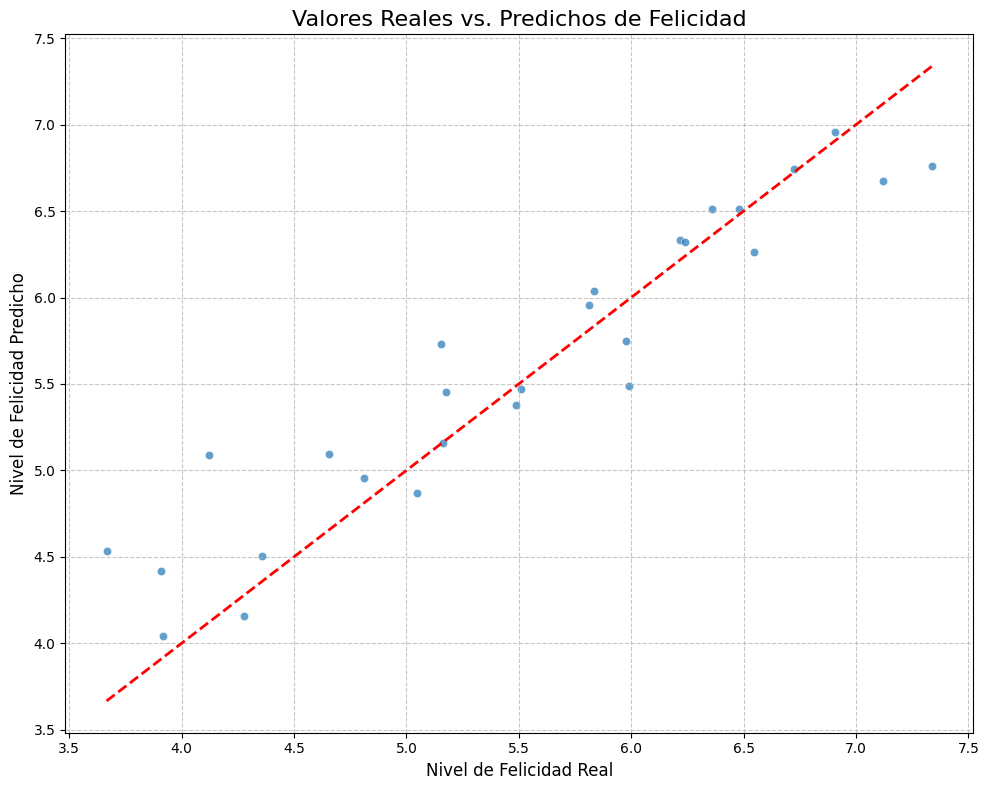

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2) # Línea de predicción perfecta

plt.title('Valores Reales vs. Predichos de Felicidad', fontsize=16)
plt.xlabel('Nivel de Felicidad Real', fontsize=12)
plt.ylabel('Nivel de Felicidad Predicho', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

# Definir las variables independientes (features) y la variable dependiente (target)
X = df_final[['GDP_per_capita', 'Family', 'Esperanza_vida', 'Trust..Government.Corruption.']]
y = df_final['Felicidad_y']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal múltiple
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
r_squared = r2_score(y_test, y_pred)

print("\nCoeficientes del modelo:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.3f}")

print(f"\nIntercepto del modelo: {model.intercept_:.3f}")
print(f"R-cuadrado del modelo: {r_squared:.3f}")


Coeficientes del modelo:
GDP_per_capita: 0.830
Family: 1.378
Esperanza_vida: 1.441
Trust..Government.Corruption.: 1.600

Intercepto del modelo: 2.477
R-cuadrado del modelo: 0.872


En esta sección se presenta la comparación entre los niveles de felicidad reales y los predichos por el modelo de regresión lineal múltiple. Debido a que algunas variables no estaban disponibles para todos los países, el análisis se limitó a los registros con información completa, lo que garantiza la integridad estadística del estudio aunque reduzca el tamaño de la muestra original.

Metodológicamente, se optó por una gráfica de Valores Reales vs. Predichos para visualizar el ajuste del modelo en un plano bidimensional, superando la limitación de representar gráficamente múltiples dimensiones de forma simultánea. La predicción se calcula sumando el intercepto del modelo con el producto de cada coeficiente por el valor de su variable correspondiente (GDP, apoyo social, salud y confianza). Esta visualización permite identificar qué tan cerca están las estimaciones del modelo de la realidad observada: entre más se agrupen los puntos sobre la línea diagonal, mayor es la capacidad explicativa de nuestras variables combinadas."

###Conclusiones
Al observar las dos gráficas, tanto la regresión lineal simple, y la regresión lineal múltiple, podems observar que ambas son del mismo tipo, directamente proporcionales, donde la felicidad sube acorde al aumento de las diferentes variables comparadas. Con esto se puede inducir que la felicidad se ve influenciada por varios factores externos, siendo el dinero, la familia, la salud o las acciones del gobierno tienen influencia directa sobre la felicidad del país.